<a href="https://colab.research.google.com/github/vladijarosz/VJaroszewski-econ/blob/main/res_netas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Vamos cargar la data al codigo, tenemos gran parte en este excel.
archivo = "C:/Users/Admin/Documents/GitHub/VJaroszewski-econ/codigos/Codigos_resNet/datos/deuda multilaterales.xlsx"

deuda_multi = pd.read_excel(archivo, sheet_name="deuMult")
encajes = pd.read_excel(archivo, sheet_name="dep y encajes")
bop_1 = pd.read_excel(archivo, sheet_name="bopreal_1")
bop_2 = pd.read_excel(archivo, sheet_name="bopreal_2")
bop_3 = pd.read_excel(archivo, sheet_name="bopreal_3")
bop_4 = pd.read_excel(archivo, sheet_name="bopreal_4")


In [3]:
bop_2['fecha'] = pd.to_datetime(bop_2['fecha'])
bop_2['fecha'] = bop_2['fecha'].dt.to_period('M')

bop_1['fecha'] = pd.to_datetime(bop_1['fecha'])
bop_1['fecha'] = bop_1['fecha'].dt.to_period('M')

bop_3['fecha'] = pd.to_datetime(bop_3['fecha'])
bop_3['fecha'] = bop_3['fecha'].dt.to_period('M')

bop_4['fecha'] = pd.to_datetime(bop_4['fecha'])
bop_4['fecha'] = bop_4['fecha'].dt.to_period('M')


In [4]:
bop = (
    bop_1
    .merge(bop_2, on='fecha', how='outer')
    .merge(bop_3, on='fecha', how='outer')
    .merge(bop_4, on='fecha', how='outer')
)

In [5]:
import pandas as pd

# Asegurar que fecha sea Period mensual
bop['fecha'] = pd.PeriodIndex(bop['fecha'], freq='M')

# Poner fecha como índice
bop = bop.set_index('fecha')

# Crear rango completo mensual
rango_completo = pd.period_range(
    start=bop.index.min(),
    end=bop.index.max(),
    freq='M'
)

# Reindexar (esto agrega los meses faltantes con NaN)
bop = bop.reindex(rango_completo)

# Opcional: volver a tener fecha como columna
bop = bop.reset_index().rename(columns={'index': 'fecha'})
bop

,fecha,bopreal_1,FFj_x,FFj_y,FFj
0,2024-01,0.0,NaN,0.0,NaN
1,2024-02,NaN,0.000000,NaN,NaN
2,2024-03,NaN,NaN,NaN,NaN
3,2024-04,NaN,NaN,NaN,NaN
4,2024-05,NaN,NaN,NaN,NaN
5,2024-06,NaN,NaN,NaN,NaN
6,2024-07,NaN,166.666667,NaN,NaN
7,2024-08,NaN,166.666667,150.0,NaN
8,2024-09,NaN,166.666667,NaN,NaN
9,2024-10,250.0,166.666667,NaN,NaN


In [6]:
bop = bop.set_index('fecha')
bop['Bopreal'] = bop.sum(axis=1)
bop['bop_año'] = (
    bop['Bopreal'][::-1]
    .rolling(12)
    .sum()[::-1]
)


In [7]:
deuda_multi.index=deuda_multi['fecha']
deuda_multi['suma un año']= (
    deuda_multi["vencimiento"][::-1]
    .rolling("365D")
    .sum()[::-1]
)/1000

In [8]:
deuda_multi = deuda_multi.drop(columns=['fecha','vencimiento'])
deuda_multi=deuda_multi.rename(columns={'suma un año':'deuda_mult'})

In [9]:
encajes.index=encajes['fecha']
encajes=encajes.drop(columns=['fecha'])
encajes['dep_Nac_ext']=encajes['dep_Nac_ext']/1000
encajes['encajes_ext']=encajes['encajes_ext']/1000

In [10]:
tc_yuan_excel= "C:/Users/Admin/Documents/GitHub/VJaroszewski-econ/codigos/Codigos_resNet/datos/tc_yuan.xlsx" \


tc_yuan = pd.read_excel(tc_yuan_excel)

# Normalizar fechas a inicio de mes para hacer el merge
tc_yuan['Fecha'] = pd.to_datetime(tc_yuan['Fecha'], format='%d.%m.%Y')

tc_yuan['fecha'] = tc_yuan['Fecha'].dt.to_period('M').dt.to_timestamp()
tc_yuan['Último']=tc_yuan['Último']/10000

# Tomar el último valor disponible por mes
tc_yuan_mensual = tc_yuan.sort_values('Fecha').groupby('fecha')['Último'].last().reset_index()


swap_china = pd.DataFrame({
    'fecha': pd.date_range(start='2020-01-01', periods=75, freq='MS'),
    'yuanes': 130_000_000
})


# Merge con swap_china
swap_china = swap_china.merge(tc_yuan_mensual, on='fecha', how='left')

# Calcular monto en usd
swap_china['swap_usd'] = swap_china['yuanes'] / swap_china['Último']
swap_china['swap_usd']=swap_china['swap_usd']/1000
swap_china = swap_china.set_index('fecha')
swap_china


,yuanes,Último,swap_usd
fecha,,,
2020-01-01,130000000,6.9367,18740.899852
2020-02-01,130000000,6.9919,18592.943263
2020-03-01,130000000,7.0825,18355.100600
2020-04-01,130000000,7.0622,18407.861573
2020-05-01,130000000,7.1373,18214.170625
...,...,...,...
2025-11-01,130000000,7.0753,18373.779204
2025-12-01,130000000,6.9937,18588.157914
2026-01-01,130000000,6.9518,18700.192756


In [11]:
df=deuda_multi.merge(encajes['dep_Nac_ext'], left_index=True, right_index=True, how="left")
df_c=df.merge(encajes['otros pasivos_usd'], left_index=True, right_index=True, how="left")


In [12]:
reservas_excel = "C:/Users/Admin/Documents/GitHub/VJaroszewski-econ/codigos/Codigos_resNet/datos/reservas.xlsx"

reservas = pd.read_excel(reservas_excel)

reservas['fecha'] = pd.to_datetime(reservas['Fecha'])
reservas = reservas.set_index('fecha')
reservas

,Fecha,Reservas mensuales
fecha,,
2020-01-01,2020-01-01,44917.1
2020-02-01,2020-02-01,44790.7
2020-03-01,2020-03-01,43561.2
2020-04-01,2020-04-01,43568.4
2020-05-01,2020-05-01,42588.5
...,...,...
2026-08-01,2026-08-01,NaN
2026-09-01,2026-09-01,NaN
2026-10-01,2026-10-01,NaN


In [13]:
df=deuda_multi.merge(encajes['dep_Nac_ext'], left_index=True, right_index=True, how="left")
df_c=df.merge(encajes['otros pasivos_usd'], left_index=True, right_index=True, how="left")


df_b=df_c.merge(reservas['Reservas mensuales'], left_index=True, right_index=True, how="left")

df_a=df_b.merge(swap_china['swap_usd'], left_index=True, right_index=True, how="left")

In [ ]:
df_1=df_a.merge(encajes['encajes_ext'], left_index=True, right_index=True, how="left")


fecha_max = reservas['Reservas mensuales'].last_valid_index()

df_1 = df_1.loc['2020-01-01':fecha_max]

df_1.index = pd.to_datetime(df_1.index)
df_1.index = df_1.index.to_period('M')

df_1=df_1.merge(bop['bop_año'], left_index=True, right_index=True, how="left")
df_1['otros pasivos_usd']=df_1['otros pasivos_usd']-df_1['swap_usd']
df_1=df_1[['Reservas mensuales', 'encajes_ext', 'swap_usd','bop_año','dep_Nac_ext','otros pasivos_usd','deuda_mult']]
df_1=df_1.fillna(0)


df_1['Res_net']=df_1['Reservas mensuales']-df_1['encajes_ext']-df_1['swap_usd']-df_1['bop_año']-df_1['dep_Nac_ext']-df_1['otros pasivos_usd']
df_1['Res_Super_net']=df_1['Reservas mensuales']-df_1['encajes_ext']-df_1['swap_usd']-df_1['bop_año']-df_1['otros pasivos_usd']-df_1['deuda_mult']

In [15]:
df_1

,Reservas mensuales,encajes_ext,swap_usd,bop_año,dep_Nac_ext,otros pasivos_usd,deuda_mult,Res_net,Res_Super_net
fecha,,,,,,,,,
2020-01,44917.100000,9958.753033,18740.899852,0.0,76.596291,3969.181814,4192.466962,12171.669010,7979.202048
2020-02,44790.700000,10626.529369,18592.943263,0.0,61.961563,3890.808891,4186.475316,11618.456913,7431.981597
2020-03,43561.200000,10314.735744,18355.100600,0.0,92.408099,3339.930368,4108.444651,11459.025189,7350.580538
2020-04,43568.400000,10868.490581,18407.861573,0.0,117.816430,3382.342437,4074.359194,10791.888979,6717.529784
2020-05,42588.500000,11220.614343,18214.170625,0.0,68.050623,3386.407328,4055.867008,9699.257081,5643.390073
...,...,...,...,...,...,...,...,...,...
2025-12,41167.000000,15066.040280,18588.157914,2677.0,1969.859517,6794.624190,6668.060111,-3928.681901,-10596.742012
2026-01,44601.935484,17268.273999,18700.192756,2677.0,526.243735,9726.628799,6413.840405,-4296.403805,-10710.244210
2026-02,45475.714286,16981.173601,18955.411041,2677.0,532.790728,9406.596393,6167.413347,-3077.257477,-9244.670824


In [16]:

import plotly.graph_objects as go

# Convert index to datetime
plot_index = df_1.index.to_timestamp()

color_net = "#1f4e79"
color_super = "#a61c1c"

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_index,
    y=df_1['Res_net'],
    mode='lines',
    name='Reservas Netas',
    line=dict(color=color_net, width=3)
))

fig.add_trace(go.Scatter(
    x=plot_index,
    y=df_1['Res_Super_net'],
    mode='lines',
    name='Reservas Super Netas',
    line=dict(color=color_super, width=3)
))

# Línea cero
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black",
    opacity=0.6
)

# Últimos valores
fig.add_annotation(
    x=plot_index[-1],
    y=df_1['Res_net'].iloc[-1],
    text=f"{df_1['Res_net'].iloc[-1]:,.0f}",
    showarrow=False,
    font=dict(color=color_net, size=12)
)

fig.add_annotation(
    x=plot_index[-1],
    y=df_1['Res_Super_net'].iloc[-1],
    text=f"{df_1['Res_Super_net'].iloc[-1]:,.0f}",
    showarrow=False,
    font=dict(color=color_super, size=12)
)

fig.update_layout(

    title=dict(
        text="Reservas Internacionales del BCRA",
        x=0,
        font=dict(size=25)
    ),

    yaxis_title="Millones de USD",

    template="simple_white",

    legend=dict(
        orientation="h",
        y=1.05,
        x=0
    ),

    yaxis=dict(
        tickformat=",",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)"
    ),

    xaxis=dict(
        showgrid=False
    ),

    margin=dict(l=40, r=20, t=60, b=40)

)

fig.show()


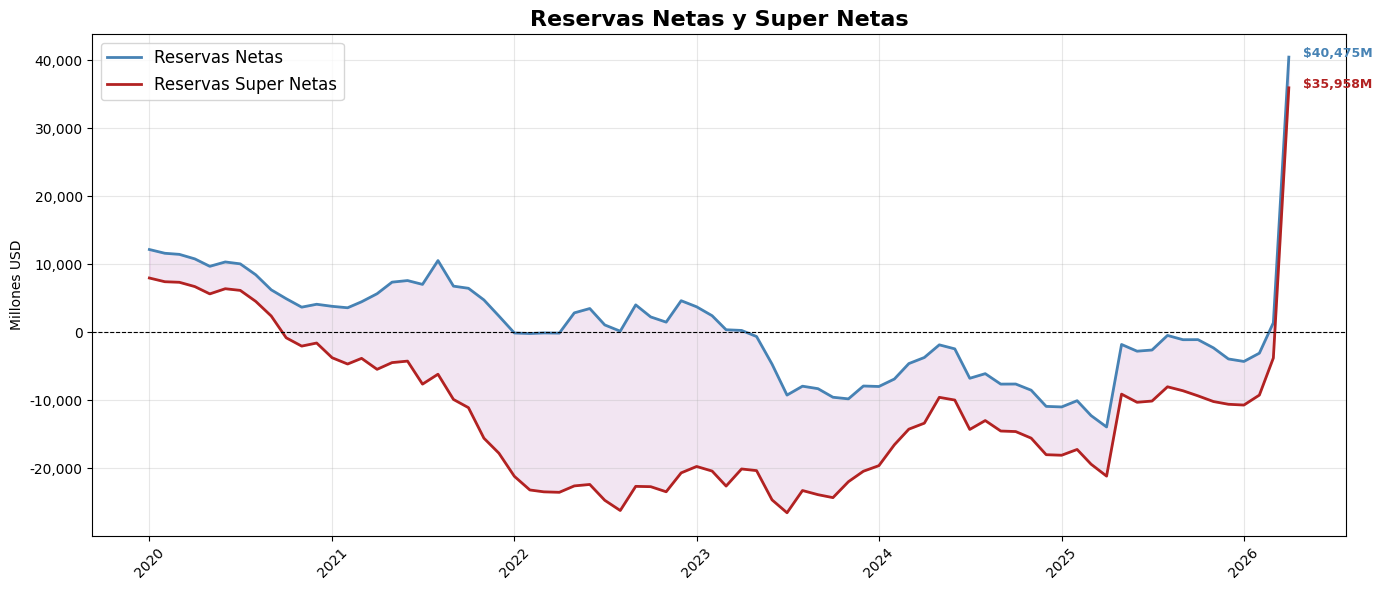

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 6))

# Convert index to datetime for plotting compatibility
plot_index = df_1.index.to_timestamp()

ax.plot(plot_index, df_1['Res_net'], label='Reservas Netas', color='steelblue', linewidth=2)
ax.plot(plot_index, df_1['Res_Super_net'], label='Reservas Super Netas', color='firebrick', linewidth=2)

ax.fill_between(plot_index, df_1['Res_net'], df_1['Res_Super_net'], alpha=0.1, color='purple')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Anotar último valor de cada serie
for col, color in [('Res_net', 'steelblue'), ('Res_Super_net', 'firebrick')]:
    ultimo = df_1[col].iloc[-1]
    ax.annotate(f'${ultimo:,.0f}M',
                xy=(plot_index[-1], ultimo),
                xytext=(10, 0), textcoords='offset points',
                color=color, fontsize=9, fontweight='bold')

ax.set_title('Reservas Netas y Super Netas', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Millones USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:

# Asegurar que el índice sea datetime
plot_index = df_1.index.to_timestamp()

fig = go.Figure()

# Línea principal
fig.add_trace(go.Scatter(
    x=plot_index,
    y=df_1["Reservas mensuales"],
    mode="lines",
    name="Reservas Brutas",
    line=dict(color="#00829A", width=3)
))

# Línea cero
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black",
    opacity=0.6
)

# Último valor
ultimo_x = plot_index[-1]
ultimo_y = df_1["Reservas mensuales"].iloc[-1]

fig.add_annotation(
    x=ultimo_x,
    y=ultimo_y,
    text=f"{ultimo_y:,.0f}",
    showarrow=False,
    font=dict(color="#00829A", size=12)
)

# Layout
fig.update_layout(
    title=dict(
        text="Reservas Brutas del BCRA",
        x=0,
        font=dict(size=18)
    ),
    yaxis_title="Millones de USD",
    template="simple_white",
    legend=dict(
        orientation="h",
        y=1.05,
        x=0
    ),
    yaxis=dict(
        tickformat=",",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)"
    ),
    xaxis=dict(
        showgrid=False
    ),
    margin=dict(l=40, r=20, t=60, b=40)
)

fig.show()

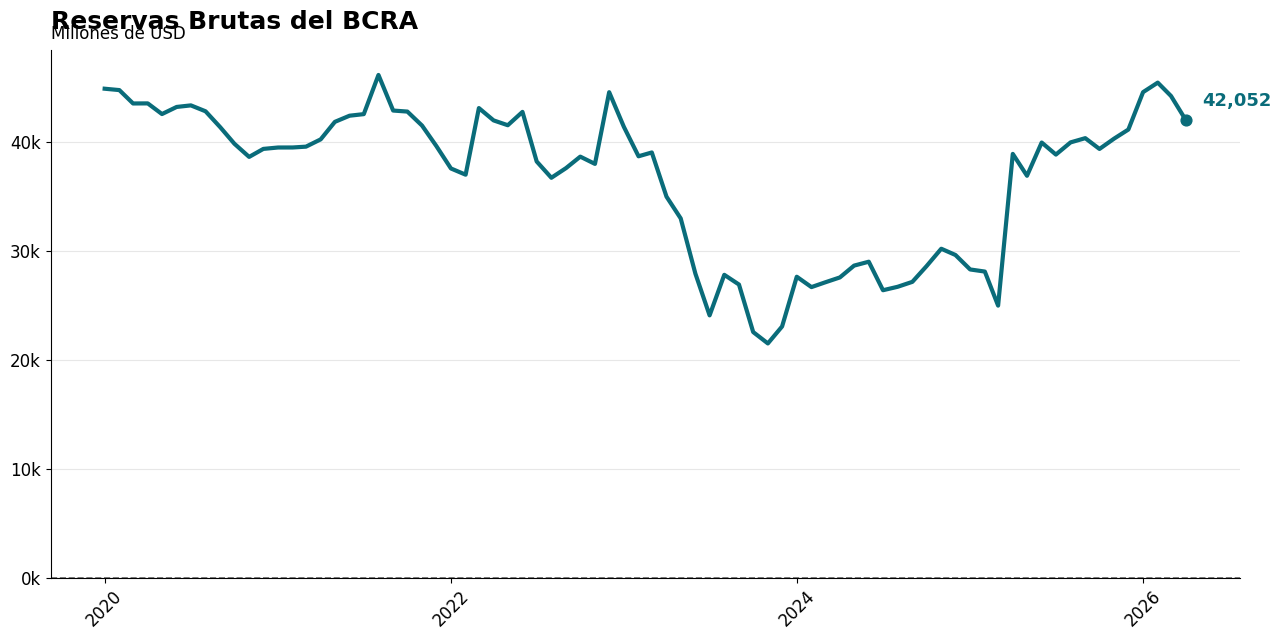

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# Datos
plot_index = df_1.index.to_timestamp()
valores = df_1["Reservas mensuales"]

# Figura (más alta para slide)
fig, ax = plt.subplots(figsize=(13, 6.5))

# Color principal
color_main = '#0A6C7A'

# Línea principal (más gruesa)
ax.plot(plot_index, valores, linewidth=3, color=color_main)

# Punto final destacado
ultimo_x = plot_index[-1]
ultimo_y = valores.iloc[-1]
ax.scatter(ultimo_x, ultimo_y, color=color_main, s=60, zorder=3)

# Línea en cero (clave en macro)
ax.axhline(0, linewidth=1.2, linestyle='--', color='black', alpha=0.6)

# Anotación GRANDE (pensado para proyector)
ax.annotate(f'{ultimo_y:,.0f}',
            xy=(ultimo_x, ultimo_y),
            xytext=(12, 10),
            textcoords='offset points',
            fontsize=13,
            fontweight='bold',
            color=color_main,
            ha='left')

# Fondo limpio
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Spines simples
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Grilla clara (pero visible en proyector)
ax.yaxis.grid(True, linewidth=0.8, alpha=0.3)
ax.xaxis.grid(False)

# EJE Y empezando en cero (lo que querías)
ax.set_ylim(bottom=0)

# Formato números GRANDES (clave)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# Eje X simple (menos ruido)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Ticks más grandes
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)

# Título GRANDE (slide)
ax.set_title('Reservas Brutas del BCRA',
             fontsize=18,
             fontweight='bold',
             loc='left',
             pad=15)

# Subtítulo claro
ax.text(0, 1.02,
        'Millones de USD',
        transform=ax.transAxes,
        fontsize=12)

plt.tight_layout()
plt.savefig('reservas_brutas_slide.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
import plotly.graph_objects as go

# Índice a datetime
plot_index = df_1.index.to_timestamp()

# Componentes (todos positivos para stacking)
res_net = df_1["Res_net"]
encajes = df_1["encajes_ext"]
swap = df_1["swap_usd"]
bop = df_1["bop_año"]
dep = df_1["dep_Nac_ext"]
otros = df_1["otros pasivos_usd"]

fig = go.Figure()

# Reservas netas (base)
fig.add_trace(go.Scatter(
    x=plot_index,
    y=res_net,
    mode='lines',
    name='Reservas Netas',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#1f4e79"
))

# Componentes
fig.add_trace(go.Scatter(
    x=plot_index,
    y=encajes,
    mode='lines',
    name='Encajes',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#7fb3d5"
))

fig.add_trace(go.Scatter(
    x=plot_index,
    y=swap,
    mode='lines',
    name='Swap China',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#f7dc6f"
))

fig.add_trace(go.Scatter(
    x=plot_index,
    y=bop,
    mode='lines',
    name='BOPREAL',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#f5b041"
))

fig.add_trace(go.Scatter(
    x=plot_index,
    y=dep,
    mode='lines',
    name='Depósitos en USD',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#ec7063"
))

fig.add_trace(go.Scatter(
    x=plot_index,
    y=otros,
    mode='lines',
    name='Otros pasivos',
    stackgroup='one',
    line=dict(width=0.5),
    fillcolor="#af7ac5"
))

# Línea de reservas brutas encima
fig.add_trace(go.Scatter(
    x=plot_index,
    y=df_1["Reservas mensuales"],
    mode='lines',
    name='Reservas Brutas',
    line=dict(color="black", width=2)
))

# Layout
fig.update_layout(
    title=dict(
        text="Composición de Reservas del BCRA",
        x=0,
        font=dict(size=22)
    ),
    yaxis_title="Millones de USD",
    template="simple_white",
    legend=dict(
        orientation="h",
        y=1.05,
        x=0
    ),
    yaxis=dict(
        tickformat=",",
        showgrid=True,
        gridcolor="rgba(0,0,0,0.1)"
    ),
    xaxis=dict(showgrid=False),
    margin=dict(l=40, r=20, t=60, b=40)
)

fig.show()